<a href="https://colab.research.google.com/github/ZionstnSLV/Daily-Data-Analyst/blob/main/sales_report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!sudo apt-get update

In [ ]:
!sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic


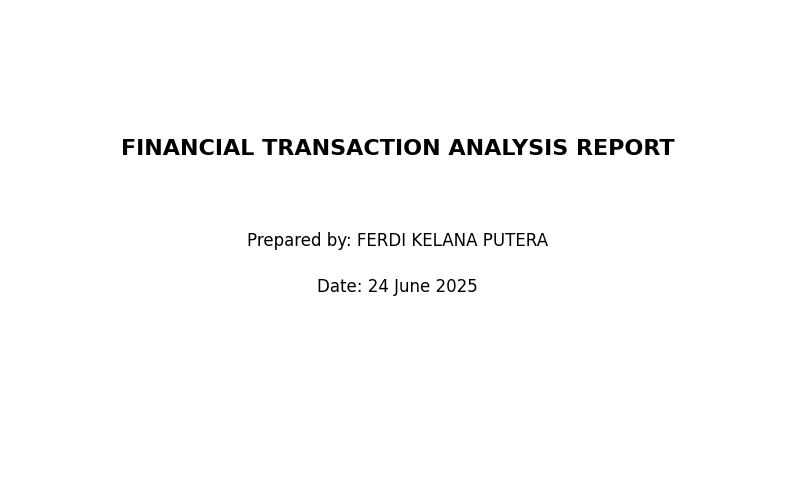

In [23]:
import matplotlib.pyplot as plt
from datetime import datetime

# Data analysis code sebelumnya...

# Buat halaman judul/cover
plt.figure(figsize=(10, 6))
plt.text(0.5, 0.7, "FINANCIAL TRANSACTION ANALYSIS REPORT",
         ha='center', va='center', fontsize=16, fontweight='bold')
plt.text(0.5, 0.5, "Prepared by: FERDI KELANA PUTERA",
         ha='center', va='center', fontsize=12)
plt.text(0.5, 0.4, f"Date: {datetime.now().strftime('%d %B %Y')}",
         ha='center', va='center', fontsize=12)
plt.axis('off')  # Matikan axis
plt.show()

#  Data Loading & Initial Exploration

**Objective:**

    Load the dataset and perform initial checks for structure, missing values, and basic statistics.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [1]:
from google.colab import files
import pandas as pd
import io
uploaded = files.upload()

for fn in uploaded.keys():
  print('user uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))

Saving test_1.csv to test_1.csv
user uploaded file "test_1.csv" with length 48731 bytes


In [3]:
print("Data Overview:")
print(df.info())

Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         1000 non-null   object
 1   Description  1000 non-null   object
 2   Deposits     1000 non-null   object
 3   Withdrawls   1000 non-null   object
 4   Balance      1000 non-null   object
dtypes: object(5)
memory usage: 39.2+ KB
None


In [4]:
print("\nFirst 5 Rows:")
print(df.head())


First 5 Rows:
          Date Description    Deposits Withdrawls     Balance
0  20-Aug-2020      Cheque    3,391.02      00.00   83,839.30
1  20-Aug-2020         ATM  147,844.20      00.00  231,683.50
2  20-Aug-2020        IMPS   17,192.00      00.00  248,875.50
3  21-Aug-2020    Transfer       08.00      00.00  248,883.50
4  21-Aug-2020    Purchase       00.00  82,961.17  165,922.33


In [5]:
print("\nDescriptive Statistics:")
print(df.describe())


Descriptive Statistics:
               Date Description Deposits Withdrawls Balance
count          1000        1000     1000       1000    1000
unique           51          15      495        441     936
top     17-Sep-2020        Bill    00.00      00.00   00.00
freq             75          81      468        533      62


# Data Cleaning & Transformation

**Objective:**

    Convert monetary values from strings (e.g., "1,000.00") to numeric (float).
    Parse Date into a datetime format for time-series analysis.

In [6]:
df['Deposits'] = df['Deposits'].str.replace(',', '').astype(float)

In [7]:
df['Withdrawls'] = df['Withdrawls'].str.replace(',', '').astype(float)

In [8]:
df['Balance'] = df['Balance'].str.replace(',', '').astype(float)

In [9]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%Y')

In [10]:
df['Month'] = df['Date'].dt.month_name()

In [11]:
df['Day'] = df['Date'].dt.day_name()

In [14]:
df.describe()

,Date,Deposits,Withdrawls,Balance
count,1000,1.000000e+03,1.000000e+03,1.000000e+03
mean,2020-09-15 01:12:00.000000256,8.538883e+04,8.523763e+04,6.391821e+05
min,2020-08-20 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2020-09-04 00:00:00,0.000000e+00,0.000000e+00,9.426553e+03
50%,2020-09-16 00:00:00,4.000000e+00,0.000000e+00,2.510593e+05
75%,2020-09-27 00:00:00,2.006000e+03,5.195649e+04,9.416954e+05
max,2020-10-09 00:00:00,2.050674e+06,3.296138e+06,4.943629e+06
std,NaN,3.105901e+05,2.628950e+05,8.958291e+05


# Key Financial Metrics
**Objective:**

    Compute total deposits, withdrawals, and net cash flow.
    Identify top transaction categories by frequency and value.

In [15]:
total_deposit = df['Deposits'].sum()
total_withdrawal = df['Withdrawls'].sum()
net_flow = total_deposit - total_withdrawal

print(f"\nFinancial Summary:")
print(f"Total Deposits: ${total_deposit:,.2f}")
print(f"Total Withdrawals: ${total_withdrawal:,.2f}")
print(f"Net Cash Flow: ${net_flow:,.2f}")


Financial Summary:
Total Deposits: $85,388,826.40
Total Withdrawals: $85,237,632.70
Net Cash Flow: $151,193.70


In [16]:
top_categories = df['Description'].value_counts().head(5)
print("\nTop 5 Transaction Categories (Frequency):")
print(top_categories)



Top 5 Transaction Categories (Frequency):
Description
Bill        81
RTGS        76
Cheque      70
NEFT        70
Interest    69
Name: count, dtype: int64


In [18]:
category_sum = df.groupby('Description').agg({
    'Deposits': 'sum',
    'Withdrawls': 'sum'
}).sort_values(by='Deposits', ascending=False).head(10)

print("\nTop 10 Categories by Transaction Value:")
print(category_sum)


Top 10 Categories by Transaction Value:
               Deposits  Withdrawls
Description                        
NEFT         9818262.11  4447681.83
RTGS         9179956.53  6395981.93
Commission   8847851.67  9090169.63
Transfer     7843618.32  7167465.51
Cash         7365867.53  7739332.07
ATM          7022518.69  6811573.77
Cheque       5998191.84  7027293.98
IMPS         5613035.65  2018880.90
Reversal     4977259.12  8595384.28
Bill         4605713.25  4754444.62


# Time-Series & Trend Analysis

**Objective:**

    Analyze monthly trends in deposits/withdrawals.
    Track daily balance changes over time.

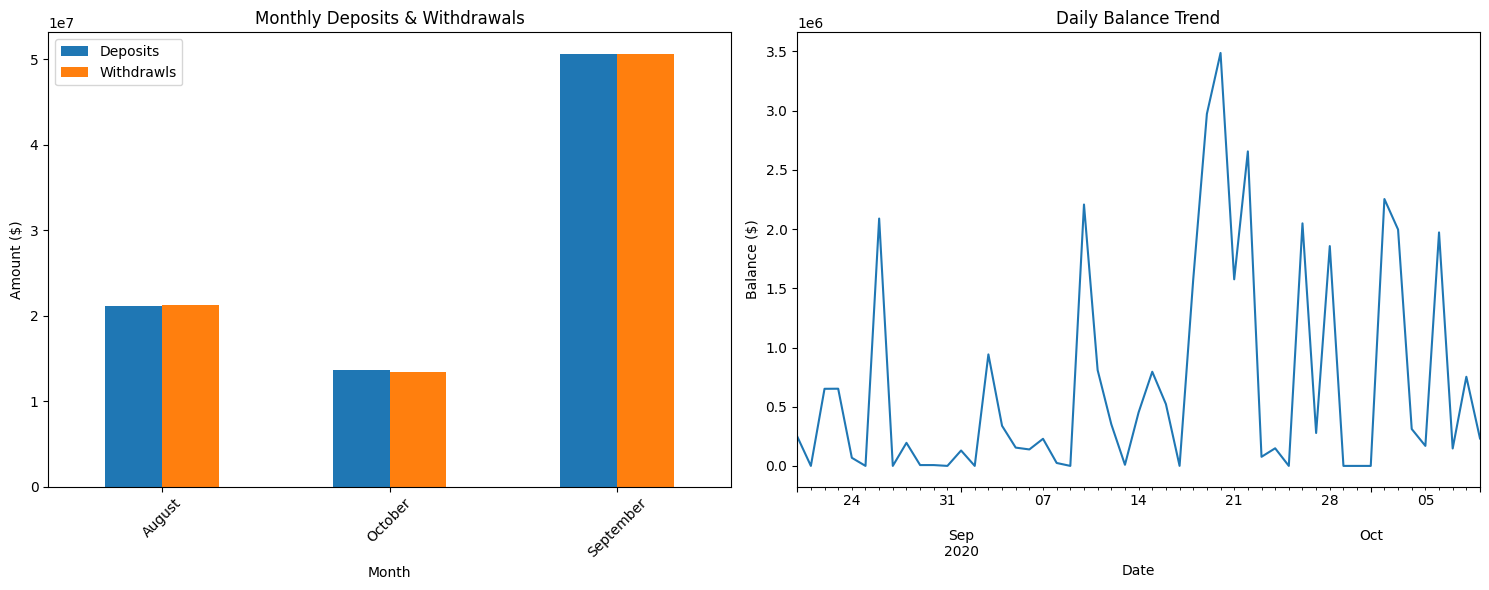

In [19]:
monthly_data = df.groupby('Month').agg({'Deposits': 'sum', 'Withdrawls': 'sum'})

daily_balance = df.groupby('Date')['Balance'].last()

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
monthly_data.plot(kind='bar', ax=plt.gca())
plt.title("Monthly Deposits & Withdrawals")
plt.ylabel("Amount ($)")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
daily_balance.plot(ax=plt.gca())
plt.title("Daily Balance Trend")
plt.ylabel("Balance ($)")
plt.tight_layout()
plt.show()


# Transaction Distribution & Outliers

**Objective:**

    Identify outliers (unusually large transactions).
    Analyze distribution of deposits/withdrawals.


Largest Deposits:
          Date Description    Deposits
136 2020-08-26        NEFT  2050673.75
192 2020-08-31        NEFT  1994907.80
649 2020-09-22        NEFT  1933335.50
526 2020-09-17        RTGS  1914618.25
593 2020-09-18         ATM  1890558.00

Largest Withdrawals:
          Date Description  Withdrawls
546 2020-09-17  Commission  3296138.38
936 2020-10-07        Cash  3113978.99
654 2020-09-23        RTGS  2559519.86
754 2020-09-27    Reversal  2382559.21
353 2020-09-11      Cheque  2210255.98


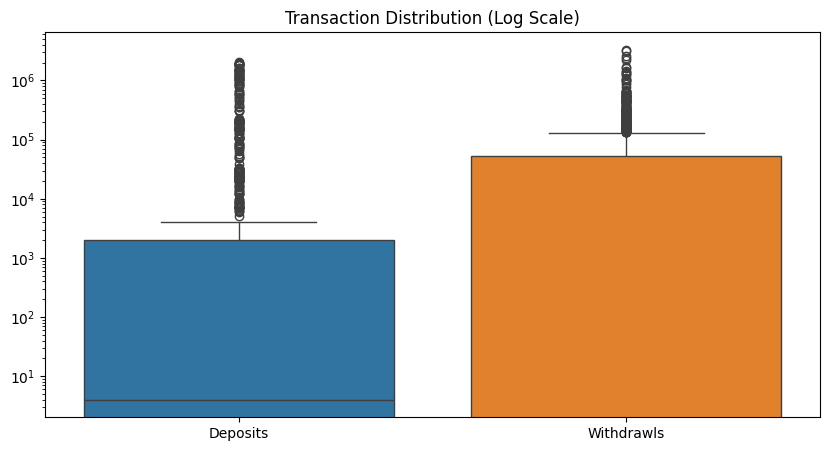

In [20]:
large_deposits = df[df['Deposits'] > df['Deposits'].quantile(0.99)]
large_withdrawals = df[df['Withdrawls'] > df['Withdrawls'].quantile(0.99)]

print("\nLargest Deposits:")
print(large_deposits[['Date', 'Description', 'Deposits']].sort_values('Deposits', ascending=False).head())

print("\nLargest Withdrawals:")
print(large_withdrawals[['Date', 'Description', 'Withdrawls']].sort_values('Withdrawls', ascending=False).head())

# Distribution plot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['Deposits', 'Withdrawls']])
plt.title("Transaction Distribution (Log Scale)")
plt.yscale('log')  # Log scale due to outliers
plt.show()

# Day-of-Week Analysis
**Objective:**

  Identify weekly patterns

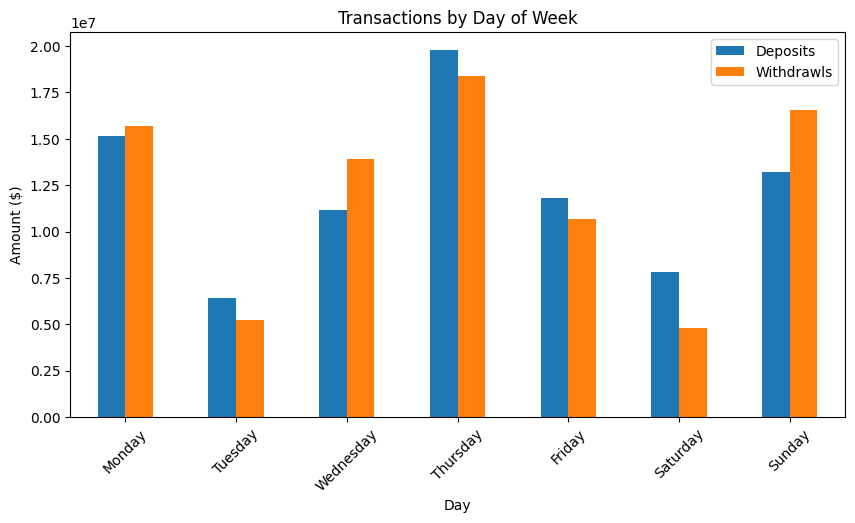

In [21]:
day_of_week = df.groupby('Day').agg({
    'Deposits': 'sum',
    'Withdrawls': 'sum'
}).reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

# Plot
plt.figure(figsize=(10, 5))
day_of_week.plot(kind='bar', ax=plt.gca())
plt.title("Transactions by Day of Week")
plt.ylabel("Amount ($)")
plt.xticks(rotation=45)
plt.show()

# Correlation Analysis
**Objective:**

  Check if deposits, withdrawals, and balance are correlated.


Correlation Matrix:
            Deposits  Withdrawls   Balance
Deposits    1.000000   -0.089227  0.387164
Withdrawls -0.089227    1.000000  0.075243
Balance     0.387164    0.075243  1.000000


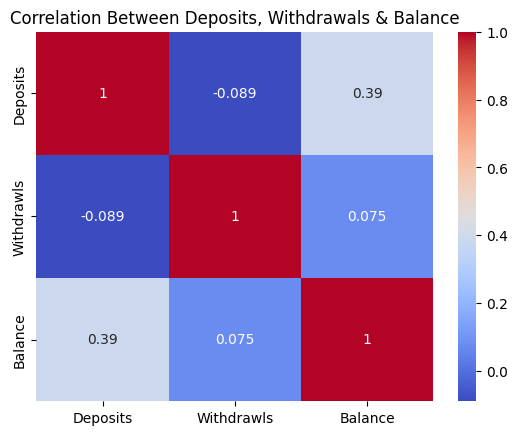

In [22]:
correlation = df[['Deposits', 'Withdrawls', 'Balance']].corr()
print("\nCorrelation Matrix:")
print(correlation)

# Heatmap visualization
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Between Deposits, Withdrawals & Balance")
plt.show()

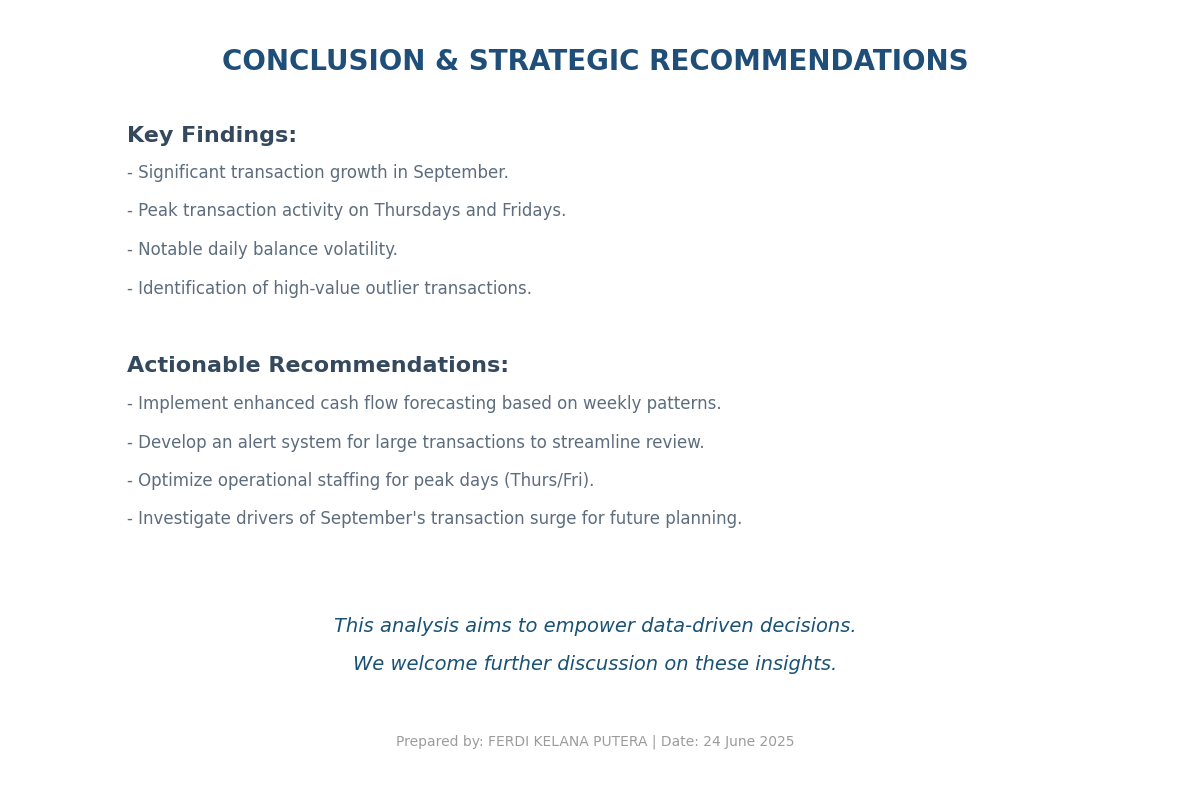

In [35]:
import matplotlib.pyplot as plt
from datetime import datetime

plt.figure(figsize=(12, 8)) # Slightly larger figure for more text

# Title
plt.text(0.5, 0.95, "CONCLUSION & STRATEGIC RECOMMENDATIONS",
         ha='center', va='top', fontsize=20, fontweight='bold', color='#1F4E79') # Dark blue for title

# Key Findings Section
plt.text(0.1, 0.85, "Key Findings:",
         ha='left', va='top', fontsize=16, fontweight='bold', color='#34495E') # Section header
plt.text(0.1, 0.80, "- Significant transaction growth in September.",
         ha='left', va='top', fontsize=12, color='#5D6D7E')
plt.text(0.1, 0.75, "- Peak transaction activity on Thursdays and Fridays.",
         ha='left', va='top', fontsize=12, color='#5D6D7E')
plt.text(0.1, 0.70, "- Notable daily balance volatility.",
         ha='left', va='top', fontsize=12, color='#5D6D7E')
plt.text(0.1, 0.65, "- Identification of high-value outlier transactions.",
         ha='left', va='top', fontsize=12, color='#5D6D7E')


# Recommendations Section
plt.text(0.1, 0.55, "Actionable Recommendations:",
         ha='left', va='top', fontsize=16, fontweight='bold', color='#34495E') # Section header
plt.text(0.1, 0.50, "- Implement enhanced cash flow forecasting based on weekly patterns.",
         ha='left', va='top', fontsize=12, color='#5D6D7E')
plt.text(0.1, 0.45, "- Develop an alert system for large transactions to streamline review.",
         ha='left', va='top', fontsize=12, color='#5D6D7E')
plt.text(0.1, 0.40, "- Optimize operational staffing for peak days (Thurs/Fri).",
         ha='left', va='top', fontsize=12, color='#5D6D7E')
plt.text(0.1, 0.35, "- Investigate drivers of September's transaction surge for future planning.",
         ha='left', va='top', fontsize=12, color='#5D6D7E')

# Call to Action / Closing Statement
plt.text(0.5, 0.20, "This analysis aims to empower data-driven decisions.",
         ha='center', va='center', fontsize=14, fontstyle='italic', color='#1A5276')
plt.text(0.5, 0.15, "We welcome further discussion on these insights.",
         ha='center', va='center', fontsize=14, fontstyle='italic', color='#1A5276')

# Prepared by / Contact
plt.text(0.5, 0.05, f"Prepared by: FERDI KELANA PUTERA | Date: {datetime.now().strftime('%d %B %Y')}",
         ha='center', va='center', fontsize=10, color='#9C9C9C')

plt.axis('off')
plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()

In [42]:
# === SEL TERAKHIR: Konversi Notebook ke PDF (Tanpa Kode Terlihat) dan Unduh ===
# PASTIKAN KAMU SUDAH MENYIMPAN NOTEBOOK INI TERLEBIH DAHULU (File -> Save)

from google.colab import files
import os

# GANTI string ini dengan NAMA FILE PERSIS notebook Colab-mu saat ini
# Contoh: "Financial_Transaction_Analysis_Report.ipynb"
notebook_name = "sales_report.ipynb" # <--- GANTI INI DENGAN NAMA SEBENARNYA!

# Perintah untuk konversi ke PDF. `--no-input` menyembunyikan semua kode.
print(f"Mencoba mengkonversi '{notebook_name}' ke PDF...")
!jupyter nbconvert "{notebook_name}" --to pdf --no-input

# Konfirmasi jika berhasil dibuat dan siap diunduh
pdf_output_name = notebook_name.replace('.ipynb', '.pdf')
print(f"\nProses konversi selesai. Mencari file: {pdf_output_name}")

# Cek apakah file sudah ada sebelum mencoba mengunduh
if os.path.exists(pdf_output_name):
    print(f"File PDF '{pdf_output_name}' ditemukan. Mengunduh...")
    files.download(pdf_output_name)
else:
    print(f"ERROR: File PDF '{pdf_output_name}' TIDAK ditemukan.")
    print("Pastikan nama notebook sudah benar (case-sensitive) dan tidak ada error saat konversi.")
    print("Coba cek output di atas untuk pesan error dari nbconvert.")
    print("Jika ada error LaTeX, mungkin ada masalah dengan format Markdown atau output tertentu.")

Mencoba mengkonversi 'sales_report.ipynb' ke PDF...
[NbConvertApp] WARNING | pattern 'sales_report.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equiva